In [3]:
import shap

print("SHAP installed successfully")

SHAP installed successfully


In [4]:
import os

os.makedirs("results", exist_ok=True)

print("Results folder created")

Results folder created


In [5]:
df = pd.read_csv("adult_income.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [6]:
df = df.replace("?", np.nan)

df = df.dropna()

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (30162, 15)


In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [8]:
print(df.dtypes)

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object


In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "str":

        df[col] = encoder.fit_transform(df[col])

print("Encoding completed")

Encoding completed


In [10]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0


In [11]:
X = df.drop("income", axis=1)

y = df["income"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (30162, 14)
y Shape: (30162,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24129, 14)
Testing Data: (6033, 14)


In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [14]:
explainer = shap.TreeExplainer(model)

print("SHAP Explainer Created")

SHAP Explainer Created


In [15]:
shap_values = explainer.shap_values(X_test)

print("SHAP Values Generated")

SHAP Values Generated


In [16]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

NameError: name 'plt' is not defined

In [17]:
import matplotlib.pyplot as plt

print("Matplotlib loaded")

Matplotlib loaded


<Figure size 1000x600 with 0 Axes>

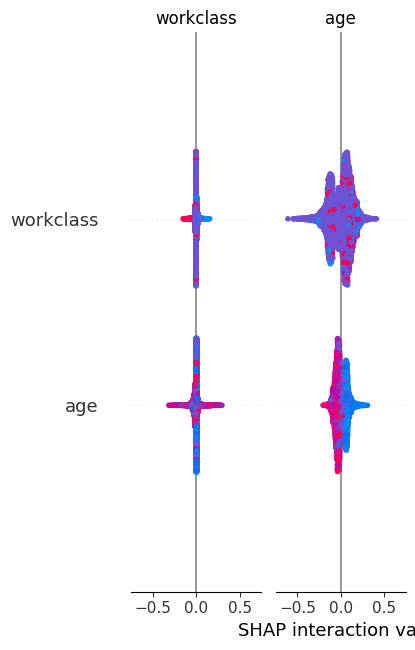

In [18]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

In [19]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [20]:
print(shap_values.shape)

(6033, 14, 2)


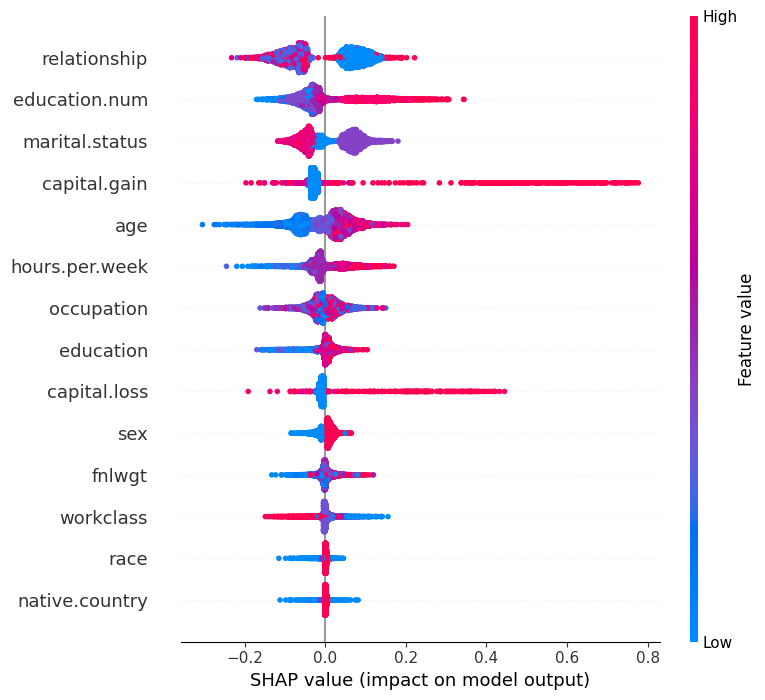

In [21]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [22]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "results/RQ2_SHAP.pdf",
    bbox_inches="tight"
)

plt.close()

print("RQ2_SHAP.pdf saved successfully")

RQ2_SHAP.pdf saved successfully


In [23]:
feature_importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Mean_Absolute_SHAP_Value":
    np.abs(shap_values[:, :, 1]).mean(axis=0)

})

feature_importance = feature_importance.sort_values(

    by="Mean_Absolute_SHAP_Value",
    ascending=False

)

feature_importance.head(10)

,Feature,Mean_Absolute_SHAP_Value
7,relationship,0.082509
4,education.num,0.064125
5,marital.status,0.057920
10,capital.gain,0.052092
0,age,0.050866
12,hours.per.week,0.034880
6,occupation,0.027256
3,education,0.016692
11,capital.loss,0.015609
9,sex,0.014848


In [24]:
feature_importance.to_csv(
    "results/RQ2_SHAP_Table.csv",
    index=False
)

print("RQ2_SHAP_Table.csv saved successfully")

RQ2_SHAP_Table.csv saved successfully


In [25]:
import os

os.listdir("results")

['RQ2_SHAP_Table.csv', 'RQ2_SHAP.pdf', 'RQ1_Metrics.csv', 'RQ1_RadarChart.pdf']